In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tau_list=np.concatenate((np.arange(0,9,2)+1,np.arange(0,200,10)+10,),axis=0)*1e-7
print(tau_list
      )

[1.0e-07 3.0e-07 5.0e-07 7.0e-07 9.0e-07 1.0e-06 2.0e-06 3.0e-06 4.0e-06
 5.0e-06 6.0e-06 7.0e-06 8.0e-06 9.0e-06 1.0e-05 1.1e-05 1.2e-05 1.3e-05
 1.4e-05 1.5e-05 1.6e-05 1.7e-05 1.8e-05 1.9e-05 2.0e-05]


In [72]:
def calculate_k_from_l(l):
    keq = l[0]/l[1]
    k = np.array((keq*l[2], keq*l[3], l[4], l[5]))
    return k

In [73]:
# Sweep the parameter from 1.0 to 2.0
parameter_sweep = np.linspace(1.495, 1.505, 10)

In [74]:
def get_analytical_dist(p_max, kappa, a, b, vol):
    lamb_n = lambda y: a*kappa[0]*y*(y-1)/vol + b*kappa[2]*vol
    mu_n = lambda y: y*kappa[3] + kappa[1]*y*(y-1)*(y-2)/(vol**2)
    
    # We will compute log(P(n)) to avoid numerical underflow/overflow
    log_p = np.zeros(p_max)
    log_p[0] = 0.0 # Arbitrary unnormalized start
    
    for n in range(1, p_max):
        log_p[n] = log_p[n-1] + np.log(lamb_n(n-1)) - np.log(mu_n(n))
        
    # Subtract max to prevent overflow when doing np.exp()
    log_p -= np.max(log_p)
    
    # Convert back to standard probability and normalize
    p_dist = np.exp(log_p)
    p_dist /= np.sum(p_dist) 
    
    return p_dist



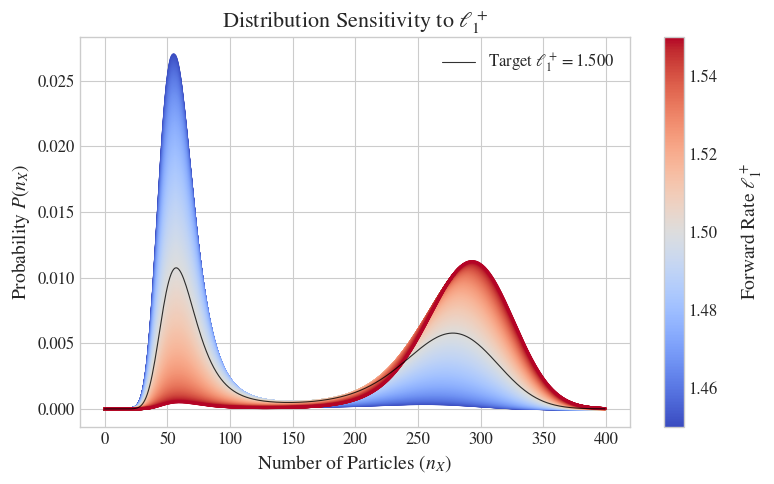

In [75]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

parameter_sweep = np.linspace(1.45, 1.55, 500) # 1.495, 1.505, 50

# 1. Set a clean scientific style
plt.style.use('seaborn-v0_8-whitegrid') # or just 'seaborn-whitegrid' depending on matplotlib version
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'mathtext.fontset': 'stix',
    'font.family': 'STIXGeneral'
})

fig, ax = plt.subplots(figsize=(8, 5))

# 2. Define a continuous colormap (e.g., 'viridis', 'plasma', or 'coolwarm')
# 'coolwarm' is great because it shows a transition from cold (low) to hot (high)
cmap = plt.get_cmap('coolwarm')


a, b = 10, 20
# Suppose l1p_values is your list/array of l1p values
l1p_min = min(parameter_sweep)
l1p_max = max(parameter_sweep)

# 3. Plot each line using the colormap
for i, l1p in enumerate(parameter_sweep):
    # Normalize the current l1p value between 0 and 1 for the colormap
    color_intensity = (l1p - l1p_min) / (l1p_max - l1p_min)
    color = cmap(color_intensity)
    x_data = np.arange(400)
    l = np.array((l1p, 1500., 150., 25., 5.75, 25.))
    k = calculate_k_from_l(l)
    y_data = get_analytical_dist(400, k, a, b, vol=8.)
    # Plot without a legend label
    ax.plot(x_data, y_data, color=color, linewidth=2, alpha=0.8)
# the exact one:
l = np.array((1.5, 1500., 150., 25., 5.75, 25.))
k = calculate_k_from_l(l)
y_data = get_analytical_dist(400, k, a, b, vol=8.)
# Plot without a legend label
ax.plot(x_data, y_data, color='black', linewidth=.8, alpha=0.8, label=r'Target $\ell_1^+ = 1.500$')
# 4. Add a colorbar instead of a legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=l1p_min, vmax=l1p_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'Forward Rate $\ell_1^+$', fontsize=14, labelpad=15)

# 5. Clean up axes and labels
ax.set_xlabel(r'Number of Particles ($n_X$)')
ax.set_ylabel(r'Probability $P(n_X)$')
ax.set_title(r'Distribution Sensitivity to $\ell_1^+$')

# Optional: Add a subtle highlight for your target value
# If you have the data for the exact target (1.500), you can plot it thicker/black
# ax.plot(x_data_target, y_data_target, color='black', linewidth=2.5, linestyle='--', label=r'Target $\ell_1^+ = 1.500$')
ax.legend()

plt.tight_layout()
plt.show()

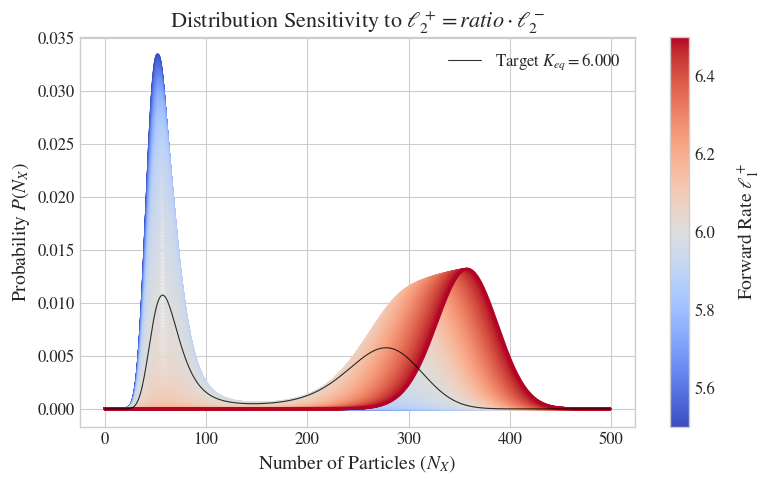

In [78]:

parameter_sweep = np.linspace(5.5, 6.5, 500) # 5.95, 6.05, 50 # 5.5, 6.5, 500

# 1. Set a clean scientific style
plt.style.use('seaborn-v0_8-whitegrid') # or just 'seaborn-whitegrid' depending on matplotlib version
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'mathtext.fontset': 'stix',
    'font.family': 'STIXGeneral'
})

fig, ax = plt.subplots(figsize=(8, 5))

# 2. Define a continuous colormap (e.g., 'viridis', 'plasma', or 'coolwarm')
# 'coolwarm' is great because it shows a transition from cold (low) to hot (high)
cmap = plt.get_cmap('coolwarm')


a, b = 10, 20
# Suppose l1p_values is your list/array of l1p values
ratio_min = min(parameter_sweep)
ratio_max = max(parameter_sweep)

# 3. Plot each line using the colormap
for i, ratio in enumerate(parameter_sweep):
    # Normalize the current l1p value between 0 and 1 for the colormap
    color_intensity = (ratio - ratio_min) / (ratio_max - ratio_min)
    color = cmap(color_intensity)
    x_data = np.arange(500)
    # l = np.array((1.5, 1500., 150., 150./ratio, 5.75, 25.))
    l = np.array((1.5, 1500., 25.*ratio, 25., 5.75, 25.))
    k = calculate_k_from_l(l)
    y_data = get_analytical_dist(500, k, a, b, vol=8.)
    # Plot without a legend label
    ax.plot(x_data, y_data, color=color, linewidth=2, alpha=0.8)
# the exact one:
l = np.array((1.5, 1500., 150., 25., 5.75, 25.))
k = calculate_k_from_l(l)
y_data = get_analytical_dist(500, k, a, b, vol=8.)
# Plot without a legend label
ax.plot(x_data, y_data, color='black', linewidth=.8, alpha=0.8, label=r'Target $K_{eq}= 6.000$')
# 4. Add a colorbar instead of a legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=ratio_min, vmax=ratio_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'Forward Rate $\ell_1^+$', fontsize=14, labelpad=15)

# 5. Clean up axes and labels
ax.set_xlabel(r'Number of Particles ($N_X$)')
ax.set_ylabel(r'Probability $P(N_X)$')
ax.set_title(r'Distribution Sensitivity to $\ell_2^+=ratio\cdot\ell_2^-$')

# Optional: Add a subtle highlight for your target value
# If you have the data for the exact target (1.500), you can plot it thicker/black
# ax.plot(x_data_target, y_data_target, color='black', linewidth=2.5, linestyle='--', label=r'Target $\ell_1^+ = 1.500$')
ax.legend()

plt.tight_layout()
plt.show()